<a href="https://colab.research.google.com/github/Moaazhe74/credit-card-approval-prediction/blob/main/credit_card_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Problem Understanding***

The objective is to build a binary classification model that predicts whether
a credit card application should be approved or rejected based on the
applicant's demographic and financial information.

The project aims to identify risky applicants while minimizing the approval
of customers who may fail to repay their credit obligations.

# ***0. IMPORTING ESSENTIAL LIBRARIES & UPLOAD DATASETS***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
app=pd.read_csv('/content/drive/MyDrive/DataSets/application_record.csv')
record=pd.read_csv('/content/drive/MyDrive/DataSets/credit_record.csv')

In [2]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [3]:
record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [4]:
print(record.shape)
print(app.shape)

(1048575, 3)
(438557, 18)


In [5]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [6]:
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


# ***1. TARGET ENGINEERING:-***

## 1.2 EXTRACT BEGIN MONTH & ADD IT TO FEATURES

In [7]:
begin_month=pd.DataFrame(record.groupby(["ID"])["MONTHS_BALANCE"].agg(min))
begin_month=begin_month.rename(columns={'MONTHS_BALANCE':'begin_month'})
begin_month

,begin_month
ID,
5001711,-3
5001712,-18
5001713,-21
5001714,-14
5001715,-59
...,...
5150482,-28
5150483,-17
5150484,-12


In [8]:
record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [9]:
begin_month=begin_month.reset_index()
df=app.merge(begin_month,on='ID',how='left')
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-15.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-14.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,-29.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-4.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-26.0


In [10]:
df.shape

(438557, 19)

In [11]:
record.shape

(1048575, 3)

In [12]:
record.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


## 1.3 DECIDE THE CREDIT APPROVAL ON THE LAST 6 MONTHS FOR CUSTOMER ONLY

In [13]:
status_map = {
    'X': -1,   # no loan
    'C': 0,    # paid
    '0': 1,    # 1–29 dpd
    '1': 2,    # 30–59
    '2': 3,    # 60–89
    '3': 4,    # 90–119
    '4': 5,    # 120–149
    '5': 6     # 150+
}
record['STATUS_NUM'] = record['STATUS'].map(status_map)

In [14]:
recent_6month = (
    record
    .sort_values(['ID', 'MONTHS_BALANCE'], ascending=[True, False])
    .groupby('ID')
    .head(6)
)

In [15]:
recent_agg = recent_6month.groupby('ID').agg(
    recent_max_delay=('STATUS_NUM', 'max'),
    recent_late_count_30=('STATUS_NUM', lambda x: (x >= 2).sum()),
    recent_late_count_60=('STATUS_NUM', lambda x: (x >= 3).sum()),
    recent_late_count_1_29=('STATUS_NUM', lambda x: (x == 1).sum())
).reset_index()

In [16]:
history_agg = record.groupby('ID').agg(
    ever_90_plus=('STATUS_NUM', lambda x: int((x >= 4).any())),
    ever_writeoff=('STATUS_NUM', lambda x: int((x == 6).any())),
    total_60_plus=('STATUS_NUM', lambda x: (x >= 3).sum())
).reset_index()

In [17]:
agg = recent_agg.merge(history_agg, on='ID', how='left')

In [18]:
agg['TARGET_RISKY'] = (
    # Recent 6 months
    (agg['recent_late_count_60'] >= 1) |      # 60+ DPD once
    (agg['recent_late_count_30'] >= 2) |      # 30+ DPD twice
    (agg['recent_late_count_1_29'] >= 4) |    # 1–29 DPD four times

    # Full history
    (agg['ever_90_plus'] == 1) |              # any 90+ DPD ever
    (agg['ever_writeoff'] == 1) |             # any write-off ever
    (agg['total_60_plus'] >= 2)               # 60+ DPD twice or more ever
).astype(int)

In [19]:
df = df.merge(agg[['ID', 'TARGET_RISKY']], on='ID', how='inner')

In [20]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-15.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-14.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,-29.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-4.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-26.0,0


## 1.5 MERGE TARGET TO OUR DATASET & HANDLE TARGET NULLS BY REMOVAL

In [21]:
df['TARGET_RISKY'].value_counts()

,count
TARGET_RISKY,
0,25137
1,11320


In [22]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'begin_month',
       'TARGET_RISKY'],
      dtype='object')

In [23]:
df_model=df.copy()

# ***2. EDA***

In [24]:
df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-15.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-14.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,-29.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-4.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-26.0,0


In [25]:
pd.options.display.float_format = '{:.2f}'.format
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36457.00,5078227.00,41875.24,5008804.00,5042028.00,5074614.00,5115396.00,5150487.00
CNT_CHILDREN,36457.00,0.43,0.74,0.00,0.00,0.00,1.00,19.00
AMT_INCOME_TOTAL,36457.00,186685.74,101789.23,27000.00,121500.00,157500.00,225000.00,1575000.00
DAYS_BIRTH,36457.00,-15975.17,4200.55,-25152.00,-19438.00,-15563.00,-12462.00,-7489.00
DAYS_EMPLOYED,36457.00,59262.94,137651.33,-15713.00,-3153.00,-1552.00,-408.00,365243.00
FLAG_MOBIL,36457.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
FLAG_WORK_PHONE,36457.00,0.23,0.42,0.00,0.00,0.00,0.00,1.00
FLAG_PHONE,36457.00,0.29,0.46,0.00,0.00,0.00,1.00,1.00
FLAG_EMAIL,36457.00,0.09,0.29,0.00,0.00,0.00,0.00,1.00
CNT_FAM_MEMBERS,36457.00,2.20,0.91,1.00,2.00,2.00,3.00,20.00


In [26]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [27]:
df_model.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [28]:
for i in df_model.columns:
  print(f'column {i} has {df_model[i].nunique()} uniques')
  print('===========')
  print(df_model[i].unique())
  print('**************************************************************')

column ID has 36457 uniques
[5008804 5008805 5008806 ... 5149838 5150049 5150337]
**************************************************************
column CODE_GENDER has 2 uniques
['M' 'F']
**************************************************************
column FLAG_OWN_CAR has 2 uniques
['Y' 'N']
**************************************************************
column FLAG_OWN_REALTY has 2 uniques
['Y' 'N']
**************************************************************
column CNT_CHILDREN has 9 uniques
[ 0  1  3  2  4  5 14 19  7]
**************************************************************
column AMT_INCOME_TOTAL has 265 uniques
[ 427500.   112500.   270000.   283500.   135000.   130500.   157500.
  405000.   211500.   360000.   126000.   315000.   247500.   297000.
  225000.   166500.   216000.   255150.   148500.   202500.    94500.
  450000.   180000.    90000.   765000.   382500.   144000.   229500.
  292500.    74250.    40500.   337500.   193500.   267750.   139500.
   67500.   2520

In [29]:
df_model[df_model['DAYS_EMPLOYED']==0]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY


# ***3. FEATURES ENGINEERING:-***

## 3.1 ID COLUMN REMOVAL

In [30]:
df_model.drop(columns='ID',inplace=True)
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
0,M,Y,Y,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00,-15.00,0
1,M,Y,Y,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00,-14.00,0
2,M,Y,Y,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.00,-29.00,0
3,F,N,Y,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00,-4.00,0
4,F,N,Y,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00,-26.00,0


## 3.2 CHANGE VALUES IN FLAG_OWN_CAR & FLAG_OWN_REALTY TO 0 & 1

In [31]:
df_model['FLAG_OWN_CAR']=(df_model['FLAG_OWN_CAR'].isin(['Y'])).astype(int)
df_model['FLAG_OWN_REALTY']=(df_model['FLAG_OWN_REALTY'].isin(['Y'])).astype(int)

In [32]:
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00,-15.00,0
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00,-14.00,0
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.00,-29.00,0
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00,-4.00,0
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00,-26.00,0


## 3.3 CHANGE DAYS_BIRTH COLUMN TO AGE

In [33]:
df_model['DAYS_BIRTH']=df_model['DAYS_BIRTH']/(-365.25)

In [34]:
df_model.rename(columns={'DAYS_BIRTH':'AGE'},inplace=True)
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,-4542,1,1,0,0,NaN,2.00,-15.00,0
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,-4542,1,1,0,0,NaN,2.00,-14.00,0
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,-1134,1,0,0,0,Security staff,2.00,-29.00,0
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,-3051,1,0,1,1,Sales staff,1.00,-4.00,0
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,-3051,1,0,1,1,Sales staff,1.00,-26.00,0


## 3.4 CHANGE DAYS_EMPLOYED COLUMN TO WORKING_YEARS

In [35]:
df_model['DAYS_EMPLOYED'].min()

-15713

In [36]:
df_model['DAYS_EMPLOYED']=(df_model['DAYS_EMPLOYED']/(365.25))

In [37]:
df_model['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,36457.00
mean,162.25
std,376.87
min,-43.02
25%,-8.63
50%,-4.25
75%,-1.12
max,999.98


In [38]:
df_model['DAYS_EMPLOYED']=np.abs(df_model['DAYS_EMPLOYED'])

In [39]:
df_model['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,36457.00
mean,174.30
std,371.45
min,0.05
25%,3.20
50%,6.89
75%,15.55
max,999.98


In [40]:
df_model['DAYS_EMPLOYED'].max()

999.98083504449

In [41]:
df_model.rename(columns={'DAYS_EMPLOYED':'WORKING_YEARS'},inplace=True)
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,WORKING_YEARS,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,1,0,0,NaN,2.00,-15.00,0
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,1,0,0,NaN,2.00,-14.00,0
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,3.10,1,0,0,0,Security staff,2.00,-29.00,0
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,1,0,1,1,Sales staff,1.00,-4.00,0
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,1,0,1,1,Sales staff,1.00,-26.00,0


In [42]:
df_model['WORKING_YEARS'][df_model['WORKING_YEARS']>80].value_counts()

,count
WORKING_YEARS,
999.98,6135


In [43]:
df_model[df_model['WORKING_YEARS']>80]

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,WORKING_YEARS,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY
7,F,0,1,0,283500.00,Pensioner,Higher education,Separated,House / apartment,61.50,999.98,1,0,0,0,NaN,1.00,-20.00,1
8,F,0,1,0,283500.00,Pensioner,Higher education,Separated,House / apartment,61.50,999.98,1,0,0,0,NaN,1.00,-16.00,1
9,F,0,1,0,283500.00,Pensioner,Higher education,Separated,House / apartment,61.50,999.98,1,0,0,0,NaN,1.00,-17.00,1
69,F,0,1,0,315000.00,Pensioner,Secondary / secondary special,Widow,House / apartment,55.27,999.98,1,0,0,0,NaN,1.00,-40.00,0
150,F,0,1,0,112500.00,Pensioner,Secondary / secondary special,Married,House / apartment,61.11,999.98,1,0,0,0,NaN,2.00,-49.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36408,F,0,0,0,162000.00,Pensioner,Secondary / secondary special,Married,House / apartment,58.16,999.98,1,0,0,0,NaN,2.00,-28.00,1
36418,F,0,1,0,112500.00,Pensioner,Secondary / secondary special,Widow,House / apartment,58.20,999.98,1,0,1,0,NaN,1.00,-16.00,0
36432,F,0,1,0,306000.00,Pensioner,Higher education,Married,House / apartment,59.11,999.98,1,0,0,0,NaN,2.00,-17.00,1
36434,F,0,1,0,90000.00,Pensioner,Secondary / secondary special,Married,House / apartment,60.26,999.98,1,0,0,0,NaN,2.00,-39.00,1


In [44]:
df_model['NAME_EDUCATION_TYPE'][df_model['WORKING_YEARS']>80].unique()

array(['Higher education', 'Secondary / secondary special',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

* there is a value in WORKING_YEARS which is repeated 5602 equals 1043 which is
not logical and obviously it refers to customer who didn't employed once before

In [45]:
df_model['IS_UNEMPLOYED'] = (df_model['WORKING_YEARS'] > 80).astype(int)
df_model.loc[df_model['WORKING_YEARS'] > 80, 'WORKING_YEARS'] = 0
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,WORKING_YEARS,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY,IS_UNEMPLOYED
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,1,0,0,NaN,2.00,-15.00,0,0
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,1,0,0,NaN,2.00,-14.00,0,0
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,3.10,1,0,0,0,Security staff,2.00,-29.00,0,0
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,1,0,1,1,Sales staff,1.00,-4.00,0,0
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,1,0,1,1,Sales staff,1.00,-26.00,0,0


In [46]:
df_model.describe()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AGE,WORKING_YEARS,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY,IS_UNEMPLOYED
count,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00
mean,0.38,0.67,0.43,186685.74,43.74,6.02,1.00,0.23,0.29,0.09,2.20,-26.16,0.31,0.17
std,0.49,0.47,0.74,101789.23,11.50,6.48,0.00,0.42,0.46,0.29,0.91,16.50,0.46,0.37
min,0.00,0.00,0.00,27000.00,20.50,0.00,1.00,0.00,0.00,0.00,1.00,-60.00,0.00,0.00
25%,0.00,0.00,0.00,121500.00,34.12,1.12,1.00,0.00,0.00,0.00,2.00,-39.00,0.00,0.00
50%,0.00,1.00,0.00,157500.00,42.61,4.25,1.00,0.00,0.00,0.00,2.00,-24.00,0.00,0.00
75%,1.00,1.00,1.00,225000.00,53.22,8.63,1.00,0.00,1.00,0.00,3.00,-12.00,1.00,0.00
max,1.00,1.00,19.00,1575000.00,68.86,43.02,1.00,1.00,1.00,1.00,20.00,0.00,1.00,1.00


## 3.5 REMOVE FLAG_MOBIL BEC IT HAS ONE VALUE

In [47]:
df_model.drop(columns='FLAG_MOBIL',inplace=True)
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,WORKING_YEARS,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,begin_month,TARGET_RISKY,IS_UNEMPLOYED
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,0,0,NaN,2.00,-15.00,0,0
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,0,0,NaN,2.00,-14.00,0,0
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,3.10,0,0,0,Security staff,2.00,-29.00,0,0
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,0,1,1,Sales staff,1.00,-4.00,0,0
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,0,1,1,Sales staff,1.00,-26.00,0,0


## 3.6 CHANGE begin_month TO POSITIVE VALUE

In [48]:
df_model['begin_month']=df_model['begin_month']*(-1)
df_model.rename(columns={'begin_month':'BEGIN_MONTH'},inplace=True)
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,WORKING_YEARS,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,BEGIN_MONTH,TARGET_RISKY,IS_UNEMPLOYED
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,0,0,NaN,2.00,15.00,0,0
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,12.44,1,0,0,NaN,2.00,14.00,0,0
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,3.10,0,0,0,Security staff,2.00,29.00,0,0
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,0,1,1,Sales staff,1.00,4.00,0,0
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,8.35,0,1,1,Sales staff,1.00,26.00,0,0


## 3.7 adding new features to the model

In [49]:
df_model['INCOME_PER_PERSON'] = df_model['AMT_INCOME_TOTAL'] / df_model['CNT_FAM_MEMBERS']

df_model['CHILDREN_RATIO'] = df_model['CNT_CHILDREN'] / df_model['CNT_FAM_MEMBERS']

df_model['EMPLOYMENT_TO_AGE_RATIO'] = df_model['WORKING_YEARS'] / df_model['AGE']

df_model['AGE_GROUP'] = pd.cut(
    df_model['AGE'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '30-40', '40-50', '50-60', '60+']
)

In [50]:
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,...,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,BEGIN_MONTH,TARGET_RISKY,IS_UNEMPLOYED,INCOME_PER_PERSON,CHILDREN_RATIO,EMPLOYMENT_TO_AGE_RATIO,AGE_GROUP
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,...,0,NaN,2.00,15.00,0,0,213750.00,0.00,0.38,30-40
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,...,0,NaN,2.00,14.00,0,0,213750.00,0.00,0.38,30-40
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,...,0,Security staff,2.00,29.00,0,0,56250.00,0.00,0.05,50-60
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,...,1,Sales staff,1.00,4.00,0,0,270000.00,0.00,0.16,50-60
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,...,1,Sales staff,1.00,26.00,0,0,270000.00,0.00,0.16,50-60


# ***4. EDA***

In [51]:
df_model.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,...,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,BEGIN_MONTH,TARGET_RISKY,IS_UNEMPLOYED,INCOME_PER_PERSON,CHILDREN_RATIO,EMPLOYMENT_TO_AGE_RATIO,AGE_GROUP
0,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,...,0,NaN,2.00,15.00,0,0,213750.00,0.00,0.38,30-40
1,M,1,1,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,32.87,...,0,NaN,2.00,14.00,0,0,213750.00,0.00,0.38,30-40
2,M,1,1,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,58.79,...,0,Security staff,2.00,29.00,0,0,56250.00,0.00,0.05,50-60
3,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,...,1,Sales staff,1.00,4.00,0,0,270000.00,0.00,0.16,50-60
4,F,0,1,0,270000.00,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.32,...,1,Sales staff,1.00,26.00,0,0,270000.00,0.00,0.16,50-60


In [52]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   CODE_GENDER              36457 non-null  object  
 1   FLAG_OWN_CAR             36457 non-null  int64   
 2   FLAG_OWN_REALTY          36457 non-null  int64   
 3   CNT_CHILDREN             36457 non-null  int64   
 4   AMT_INCOME_TOTAL         36457 non-null  float64 
 5   NAME_INCOME_TYPE         36457 non-null  object  
 6   NAME_EDUCATION_TYPE      36457 non-null  object  
 7   NAME_FAMILY_STATUS       36457 non-null  object  
 8   NAME_HOUSING_TYPE        36457 non-null  object  
 9   AGE                      36457 non-null  float64 
 10  WORKING_YEARS            36457 non-null  float64 
 11  FLAG_WORK_PHONE          36457 non-null  int64   
 12  FLAG_PHONE               36457 non-null  int64   
 13  FLAG_EMAIL               36457 non-null  int64   
 14  OCCUPA

In [53]:
df_model.describe()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AGE,WORKING_YEARS,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,BEGIN_MONTH,TARGET_RISKY,IS_UNEMPLOYED,INCOME_PER_PERSON,CHILDREN_RATIO,EMPLOYMENT_TO_AGE_RATIO
count,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00,36457.00
mean,0.38,0.67,0.43,186685.74,43.74,6.02,0.23,0.29,0.09,2.20,26.16,0.31,0.17,100554.77,0.13,0.15
std,0.49,0.47,0.74,101789.23,11.50,6.48,0.42,0.46,0.29,0.91,16.50,0.46,0.37,72678.93,0.20,0.14
min,0.00,0.00,0.00,27000.00,20.50,0.00,0.00,0.00,0.00,1.00,-0.00,0.00,0.00,5625.00,0.00,0.00
25%,0.00,0.00,0.00,121500.00,34.12,1.12,0.00,0.00,0.00,2.00,12.00,0.00,0.00,56250.00,0.00,0.03
50%,0.00,1.00,0.00,157500.00,42.61,4.25,0.00,0.00,0.00,2.00,24.00,0.00,0.00,78750.00,0.00,0.11
75%,1.00,1.00,1.00,225000.00,53.22,8.63,0.00,1.00,0.00,3.00,39.00,1.00,0.00,123750.00,0.33,0.22
max,1.00,1.00,19.00,1575000.00,68.86,43.02,1.00,1.00,1.00,20.00,60.00,1.00,1.00,900000.00,2.00,0.69


In [54]:
df_model.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


In [55]:
df_model.shape

(36457, 23)

## 4.2 SPLITTING FEATURES & TARGET

In [56]:
x=df_model.drop('TARGET_RISKY',axis=1)
y=df_model[['TARGET_RISKY']]
numerical_feat=x.select_dtypes(exclude=['object'])
categorical_feat=x.select_dtypes(exclude=['number'])
print(categorical_feat.columns)
print(numerical_feat.columns)

Index(['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'AGE_GROUP'],
      dtype='object')
Index(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AGE', 'WORKING_YEARS', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS', 'BEGIN_MONTH', 'IS_UNEMPLOYED', 'INCOME_PER_PERSON',
       'CHILDREN_RATIO', 'EMPLOYMENT_TO_AGE_RATIO', 'AGE_GROUP'],
      dtype='object')


In [57]:
for i in categorical_feat.columns:
  print(f'column {i} has {categorical_feat[i].nunique()} uniques')
  print('===========')
  print(categorical_feat[i].unique())
  print('**************************************************************')

column CODE_GENDER has 2 uniques
['M' 'F']
**************************************************************
column NAME_INCOME_TYPE has 5 uniques
['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']
**************************************************************
column NAME_EDUCATION_TYPE has 5 uniques
['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
**************************************************************
column NAME_FAMILY_STATUS has 5 uniques
['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']
**************************************************************
column NAME_HOUSING_TYPE has 6 uniques
['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
**************************************************************
column OCCUPATION_TYPE has 18 uniques
[nan 'Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'D

In [58]:
for i in numerical_feat.columns:
  print(f'column {i} has {numerical_feat[i].nunique()} uniques')
  print('===========')
  print(numerical_feat[i].unique())
  print('**************************************************************')

column FLAG_OWN_CAR has 2 uniques
[1 0]
**************************************************************
column FLAG_OWN_REALTY has 2 uniques
[1 0]
**************************************************************
column CNT_CHILDREN has 9 uniques
[ 0  1  3  2  4  5 14 19  7]
**************************************************************
column AMT_INCOME_TOTAL has 265 uniques
[ 427500.   112500.   270000.   283500.   135000.   130500.   157500.
  405000.   211500.   360000.   126000.   315000.   247500.   297000.
  225000.   166500.   216000.   255150.   148500.   202500.    94500.
  450000.   180000.    90000.   765000.   382500.   144000.   229500.
  292500.    74250.    40500.   337500.   193500.   267750.   139500.
   67500.   252000.   900000.   115290.   279000.    76500.   234000.
   81000.   108000.    99000.   198000.    45000.   238500.   117000.
  153000.  1350000.   445500.   495000.    85500.   306000.   562500.
  189000.   328500.   310500.   540000.   171000.   675000.   121

In [59]:
disc_numerical_feat=df_model[['FLAG_OWN_CAR','FLAG_OWN_REALTY','CNT_CHILDREN','FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL','CNT_FAM_MEMBERS','CHILDREN_RATIO','AGE_GROUP']]
cont_numerical_feat=numerical_feat.drop(disc_numerical_feat.columns,axis=1)
print(disc_numerical_feat.columns)
print(cont_numerical_feat.columns)

Index(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'CHILDREN_RATIO',
       'AGE_GROUP'],
      dtype='object')
Index(['AMT_INCOME_TOTAL', 'AGE', 'WORKING_YEARS', 'BEGIN_MONTH',
       'IS_UNEMPLOYED', 'INCOME_PER_PERSON', 'EMPLOYMENT_TO_AGE_RATIO'],
      dtype='object')


## 4.3 VISUALIZATION FOR CONTINUOUS NUMERICAL FEATURES

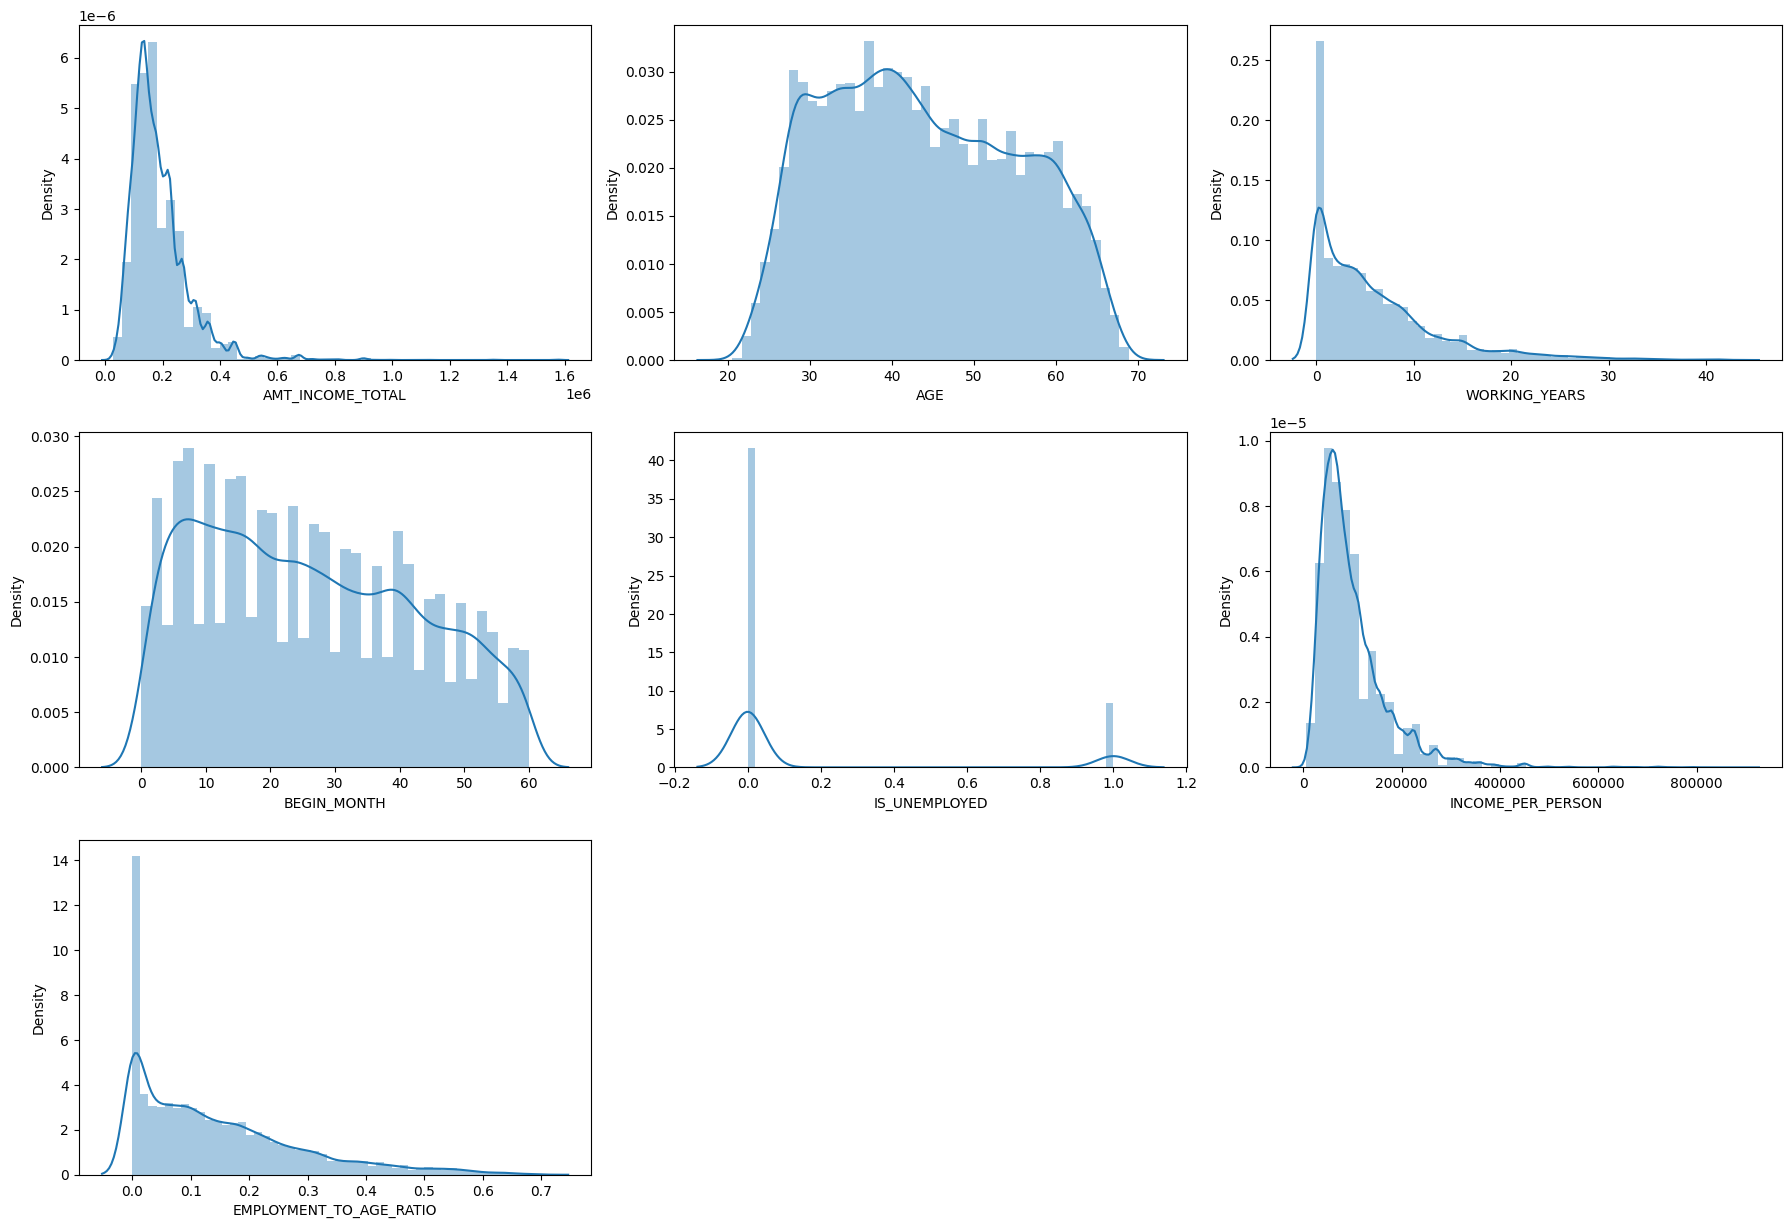

In [60]:
fig = plt.figure(figsize=(18,16))
for index,col in enumerate(cont_numerical_feat):
    plt.subplot(4,3,index+1)
    sns.distplot(cont_numerical_feat.loc[:,col].dropna())
fig.tight_layout(pad=1.0)

column AMT_INCOME_TOTAL has outliers percentage = 4.193981951339935 %
identified outliers [427500.0, 427500.0, 405000.0, 405000.0, 405000.0, 405000.0, 405000.0, 405000.0, 450000.0, 450000.0, 765000.0, 765000.0, 765000.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 900000.0, 900000.0, 450000.0, 450000.0, 450000.0, 450000.0, 1350000.0, 1350000.0, 1350000.0, 1350000.0, 1350000.0, 1350000.0, 445500.0, 445500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 427500.0, 427500.0, 427500.0, 427500.0, 495000.0, 495000.0, 495000.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 562500.0, 540000.0, 540000.0, 540000.0, 540000.0, 540000.0, 540000.0, 540000.0, 675000.0, 675000.0, 675000.0, 675000.0, 450000.0, 450000.0, 450000.0, 450000.0, 450000.0, 450000.0, 450000.0, 450

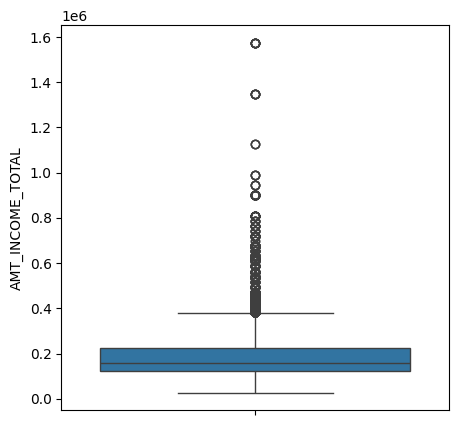

column AGE has outliers percentage = 0.0 %
identified outliers []


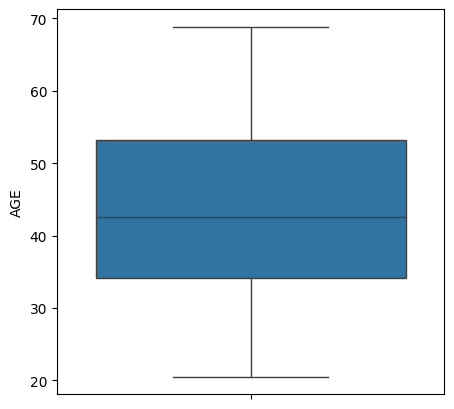

column WORKING_YEARS has outliers percentage = 4.855034698411828 %
identified outliers [29.686516084873375, 29.686516084873375, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 23.77549623545517, 24.605065023956193, 24.605065023956193, 24.605065023956193, 20.27104722792608, 20.27104722792608, 27.02258726899384, 27.02258726899384, 27.02258726899384, 27.02258726899384, 27.02258726899384, 27.02258726899384, 27.02258726899384, 27.02258726899384, 27.02258726899384, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 26.688569472963724, 29.94113620807666, 29.94113620807666, 29.94113620807666, 29.94113620807666, 

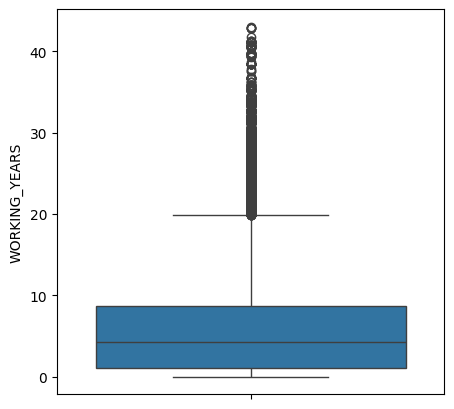

column BEGIN_MONTH has outliers percentage = 0.0 %
identified outliers []


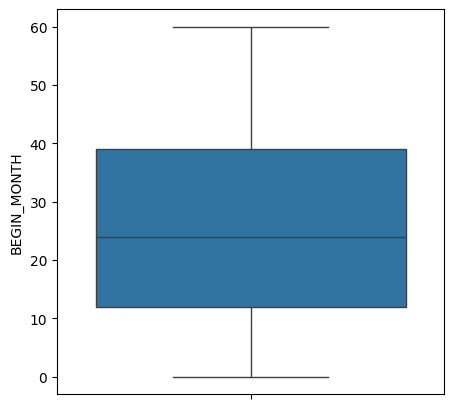

column IS_UNEMPLOYED has outliers percentage = 100.0 %
identified outliers [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 

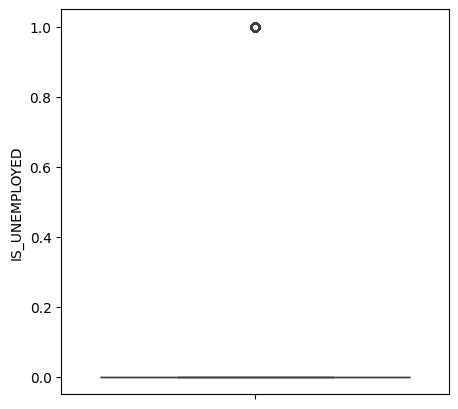

column INCOME_PER_PERSON has outliers percentage = 6.934196450613051 %
identified outliers [270000.0, 270000.0, 270000.0, 270000.0, 283500.0, 283500.0, 283500.0, 315000.0, 247500.0, 247500.0, 247500.0, 247500.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 297000.0, 270000.0, 270000.0, 270000.0, 270000.0, 270000.0, 270000.0, 315000.0, 315000.0, 255000.0, 255000.0, 255000.0, 315000.0, 315000.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 382500.0, 900000.0, 900000.0, 225000.0, 225000.0, 225000.0, 225000.0, 279000.0

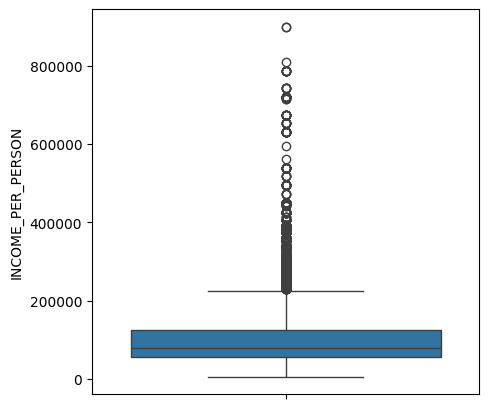

column EMPLOYMENT_TO_AGE_RATIO has outliers percentage = 2.745700414186576 %
identified outliers [0.5459443129751774, 0.5459443129751774, 0.5627426424546024, 0.5627426424546024, 0.5627426424546024, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5181523414660075, 0.5863806970509383, 0.5863806970509383, 0.5863806970509383, 0.5863806970509383, 0.5863806970509383, 0.5863806970509383, 0.5863806970509383, 0.5168594461969857, 0.5168594461969857, 0.561686218899059, 0.561686218899059, 0.561686218899059, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5574547860608735, 0.5468257692565529, 0.5468257692565529, 0.5259723137771918, 0.525

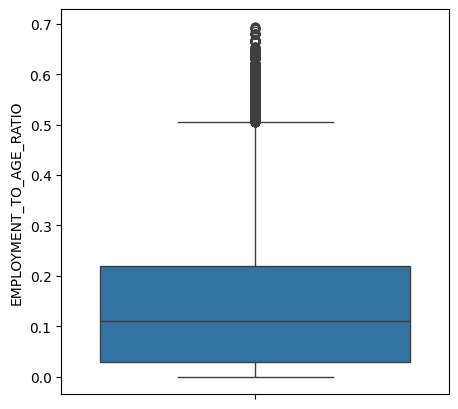

In [61]:
for k,v in cont_numerical_feat.items():
  q1=v.quantile(0.25)
  q3=v.quantile(0.75)
  irq=q3-q1
  v_out = v[ (v >= q3+irq*1.5)  |    (v <= q1-irq*1.5)]
  perc= np.shape(v_out)[0]*100/np.shape(df_model)[0]
  print(f'column {k} has outliers percentage = {perc} %')
  print(f'identified outliers {v_out.tolist()}')
  plt.figure(figsize=(5,5))
  sns.boxplot( y= k , data=df_model)
  plt.show()

## 4.4 VISUALIZATION FOR DISCRETE NUMERICAL FEATURES

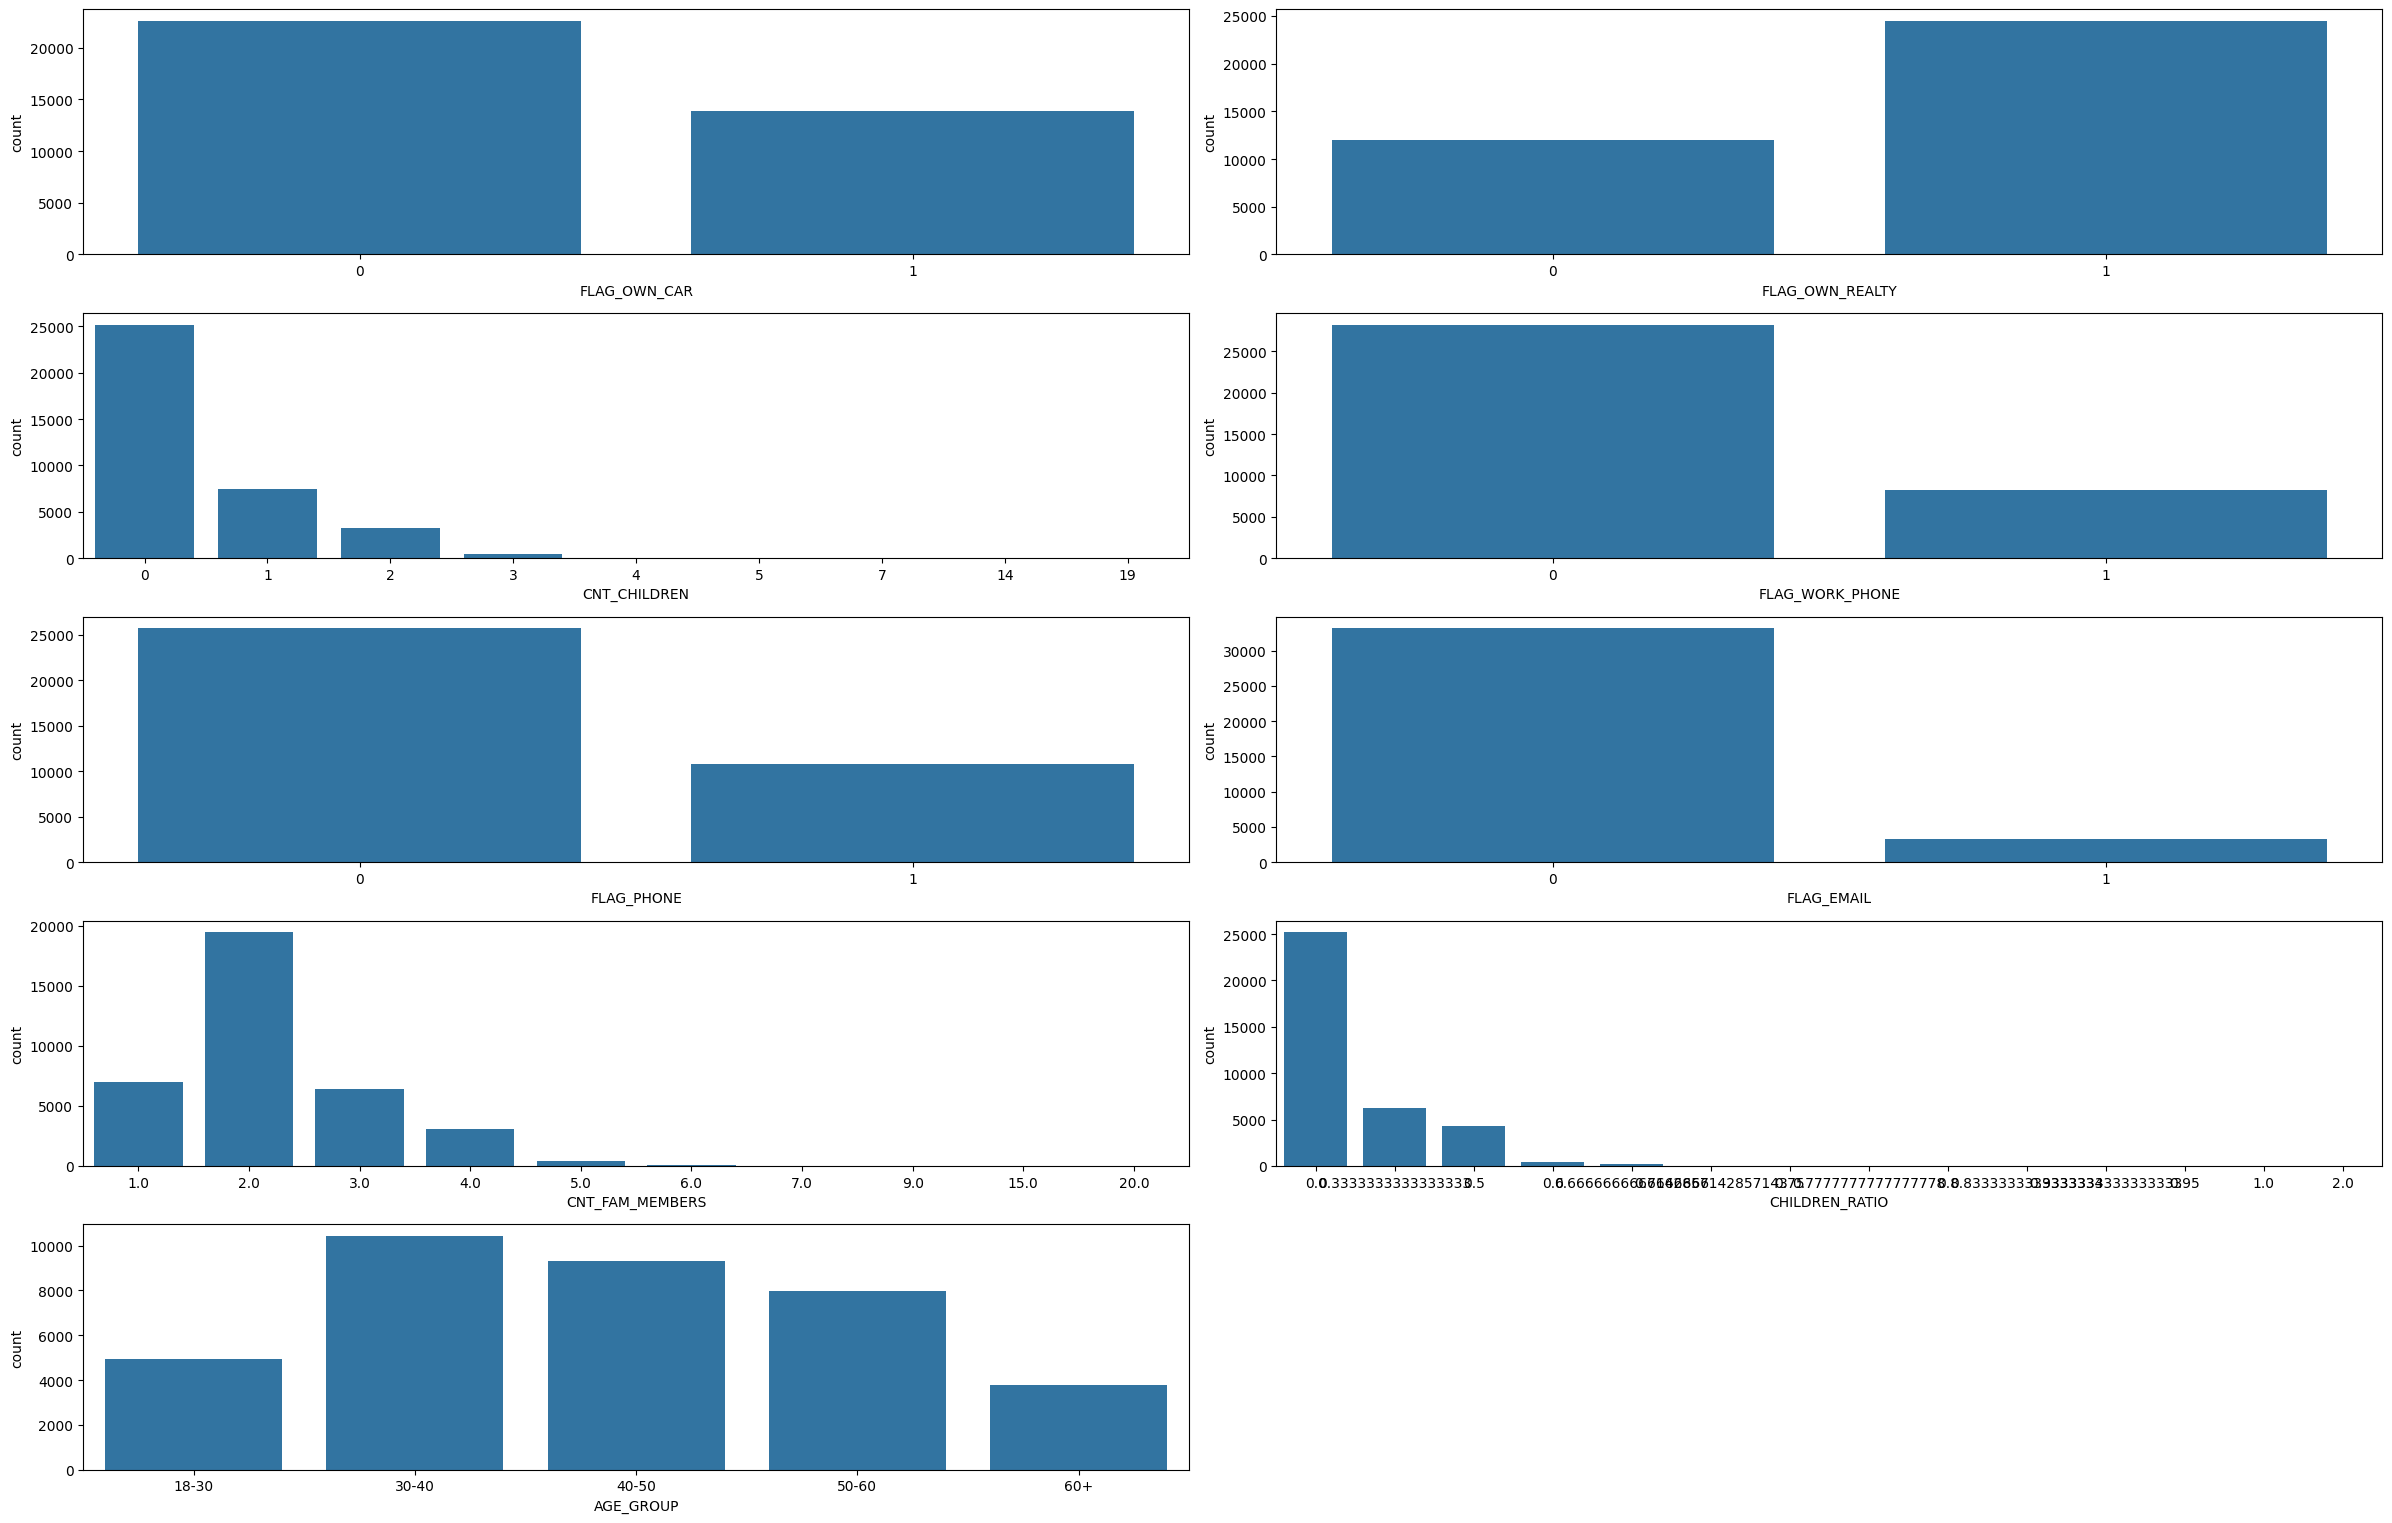

In [62]:
fig = plt.figure(figsize=(24,24))
for index,col in enumerate(disc_numerical_feat):
    plt.subplot(8,2,index+1)
    sns.countplot(x=col, data=numerical_feat.dropna())
fig.tight_layout(pad=1.0)

## 4.5 VISUALIZATION FOR CATEGORICAL FEATURES

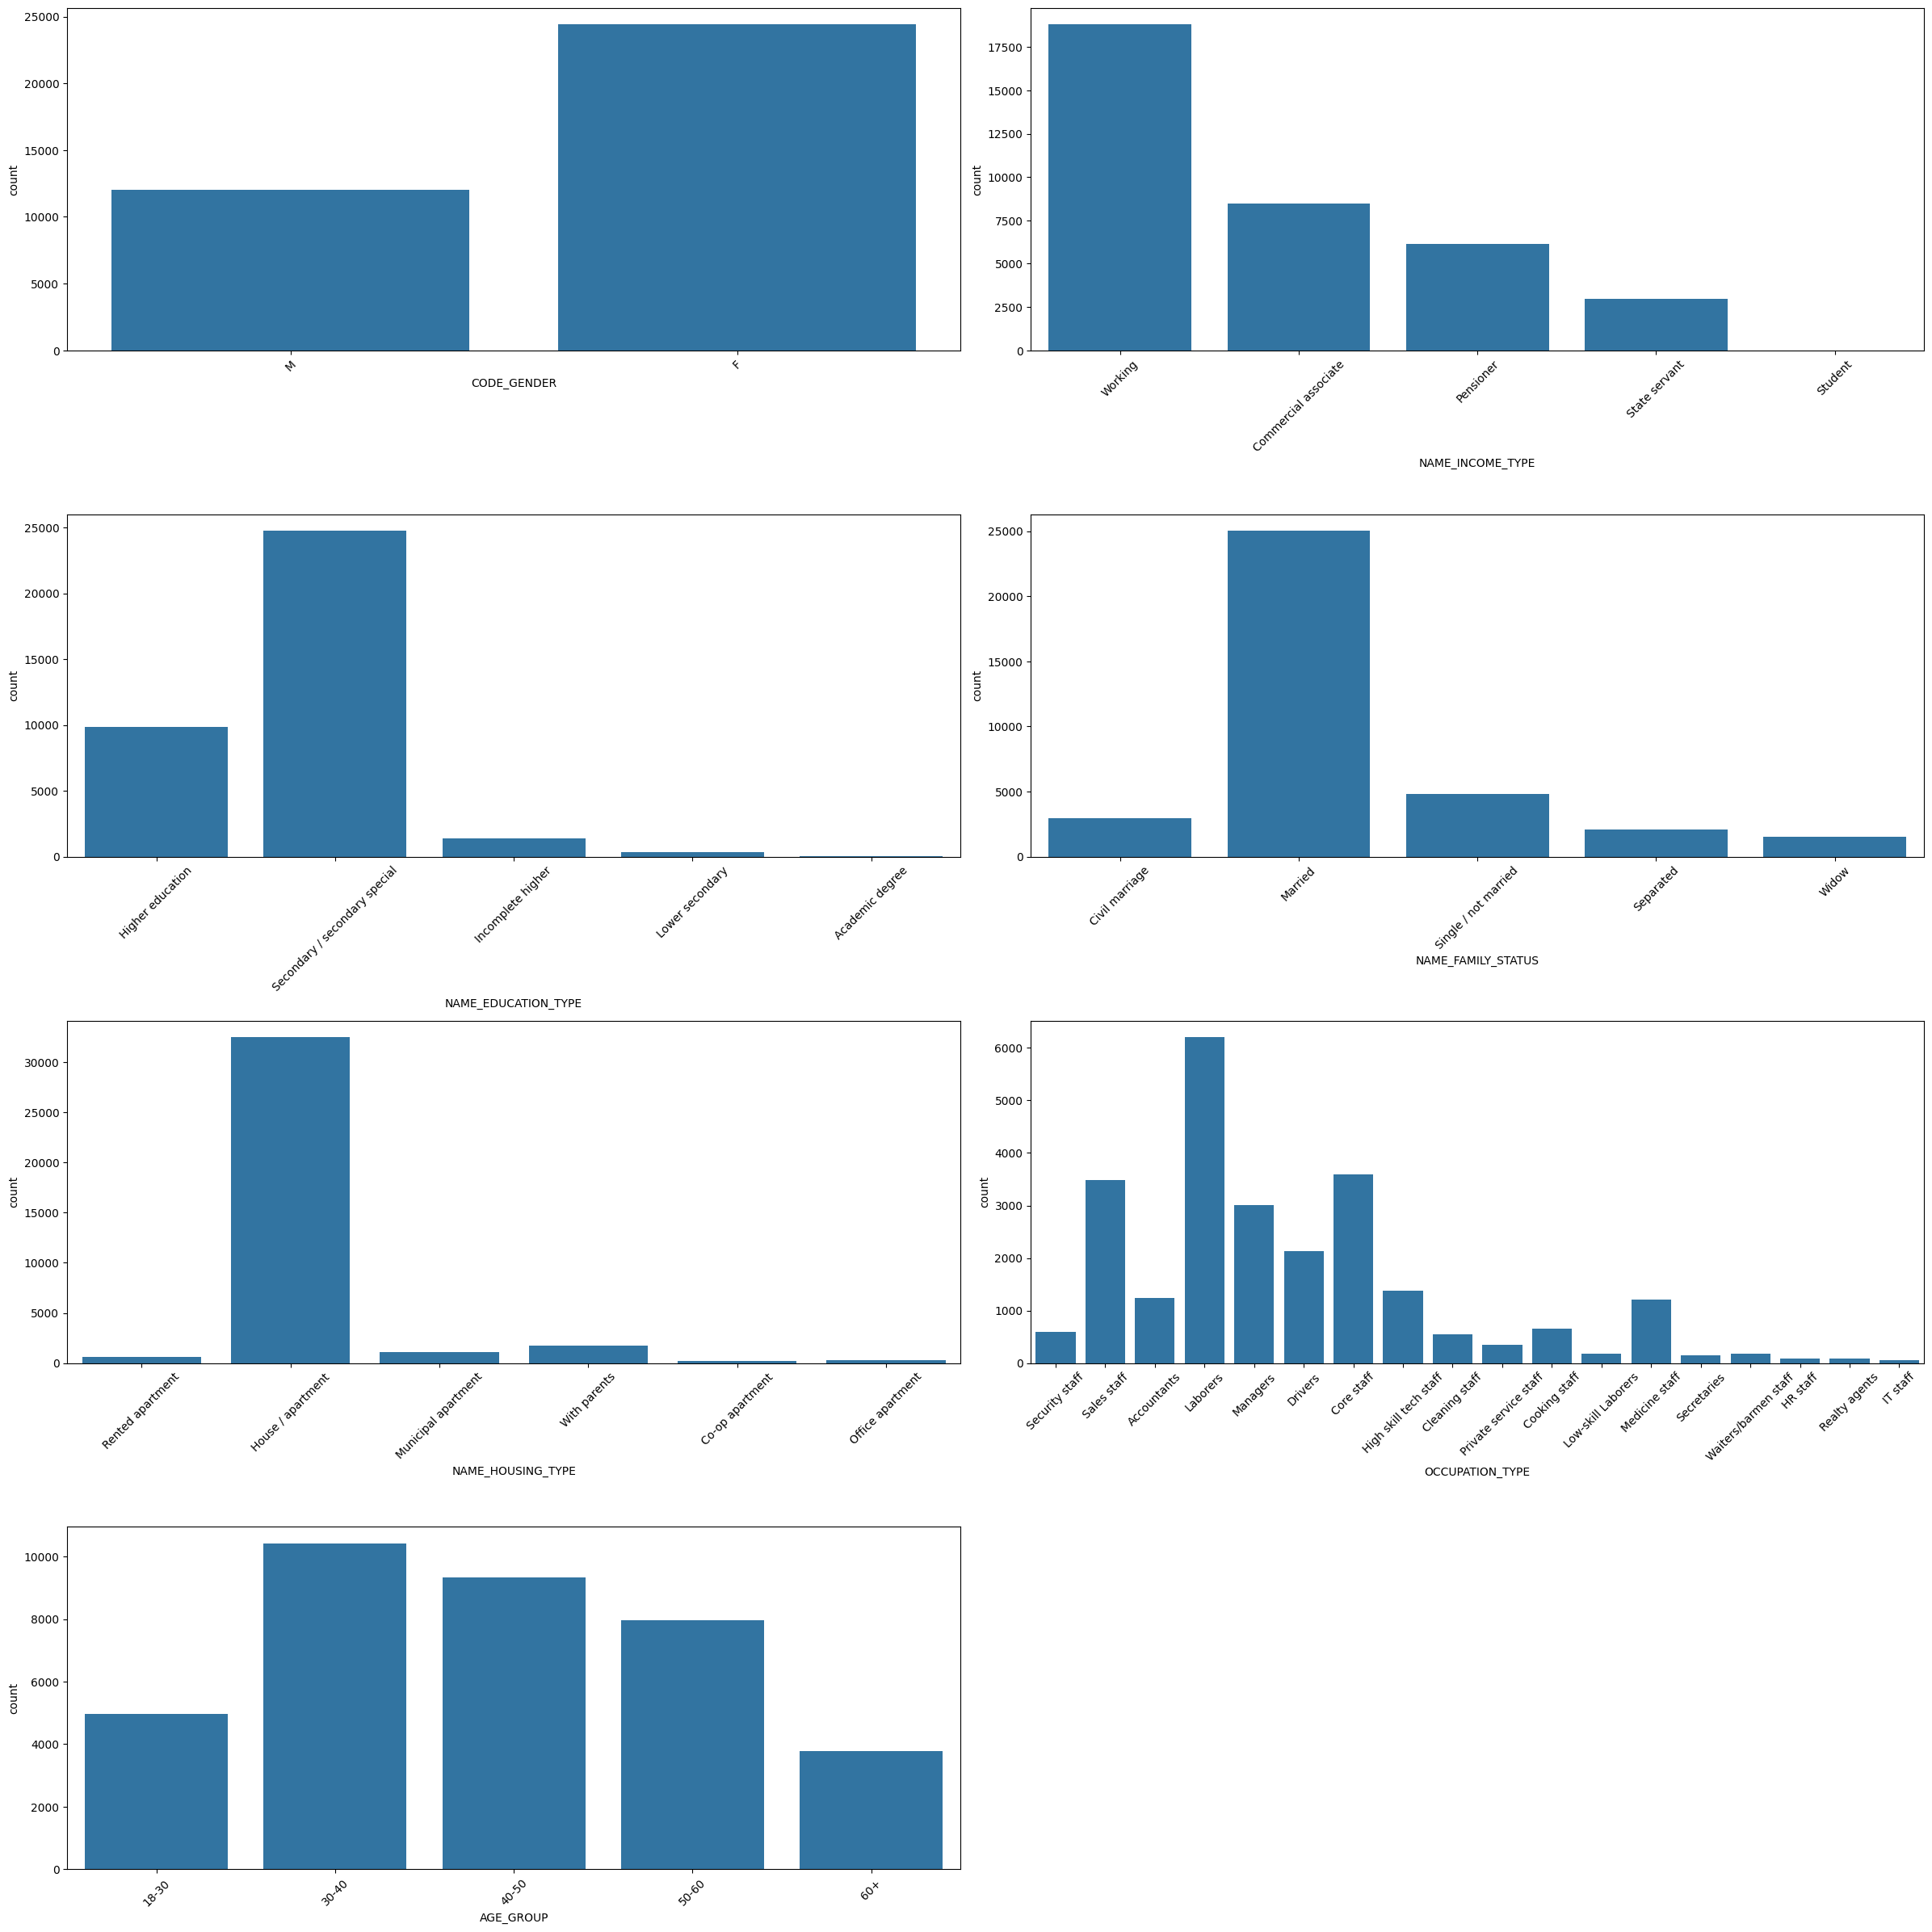

In [63]:
fig = plt.figure(figsize=(24,24))
for index in range(len(categorical_feat.columns)):
    plt.subplot(4,2,index+1)
    sns.countplot(x=categorical_feat.iloc[:,index], data=categorical_feat.dropna())
    plt.xticks(rotation=45)
fig.tight_layout(pad=1.0)

## 4.6 VISUALIZATION OF TARGET

In [64]:
df_model.columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'AGE', 'WORKING_YEARS',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'BEGIN_MONTH', 'TARGET_RISKY', 'IS_UNEMPLOYED',
       'INCOME_PER_PERSON', 'CHILDREN_RATIO', 'EMPLOYMENT_TO_AGE_RATIO',
       'AGE_GROUP'],
      dtype='object')

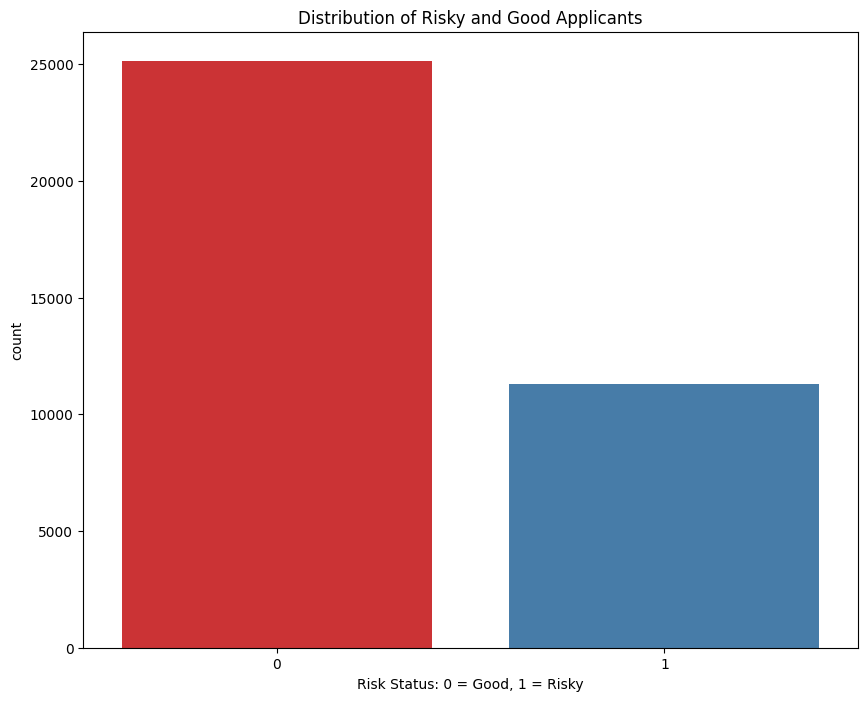

In [65]:
f, ax = plt.subplots(figsize=(10, 8))
ax = sns.countplot(x="TARGET_RISKY", data=df_model, palette="Set1")
ax.set_title("Distribution of Risky and Good Applicants")
ax.set_xlabel("Risk Status: 0 = Good, 1 = Risky")
plt.show()

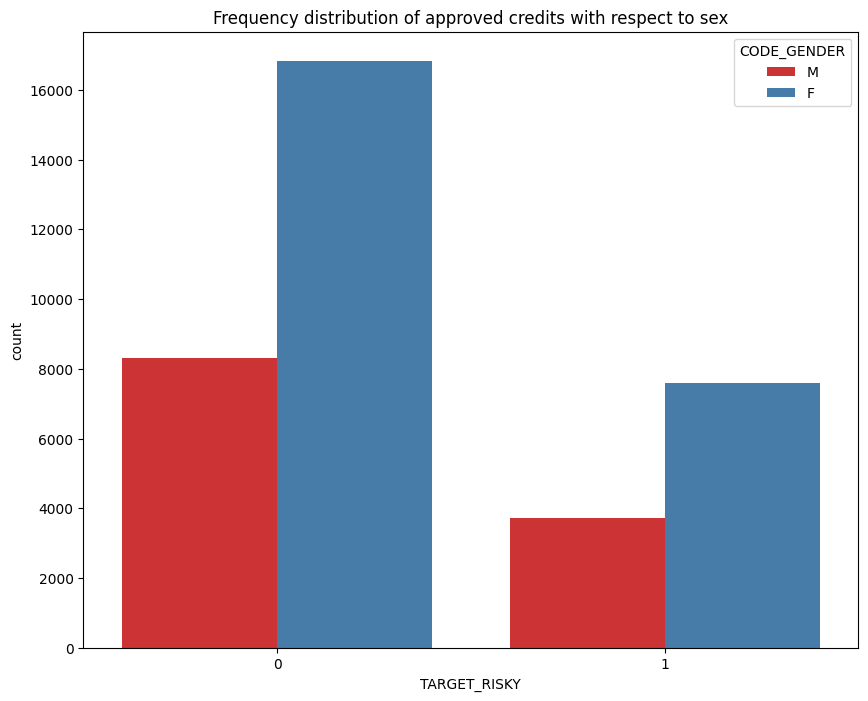

In [66]:
f, ax = plt.subplots(figsize=(10, 8))
ax = sns.countplot(x="TARGET_RISKY",hue='CODE_GENDER', data=df_model, palette="Set1")
ax.set_title("Frequency distribution of approved credits with respect to sex")
plt.show()

<Axes: >

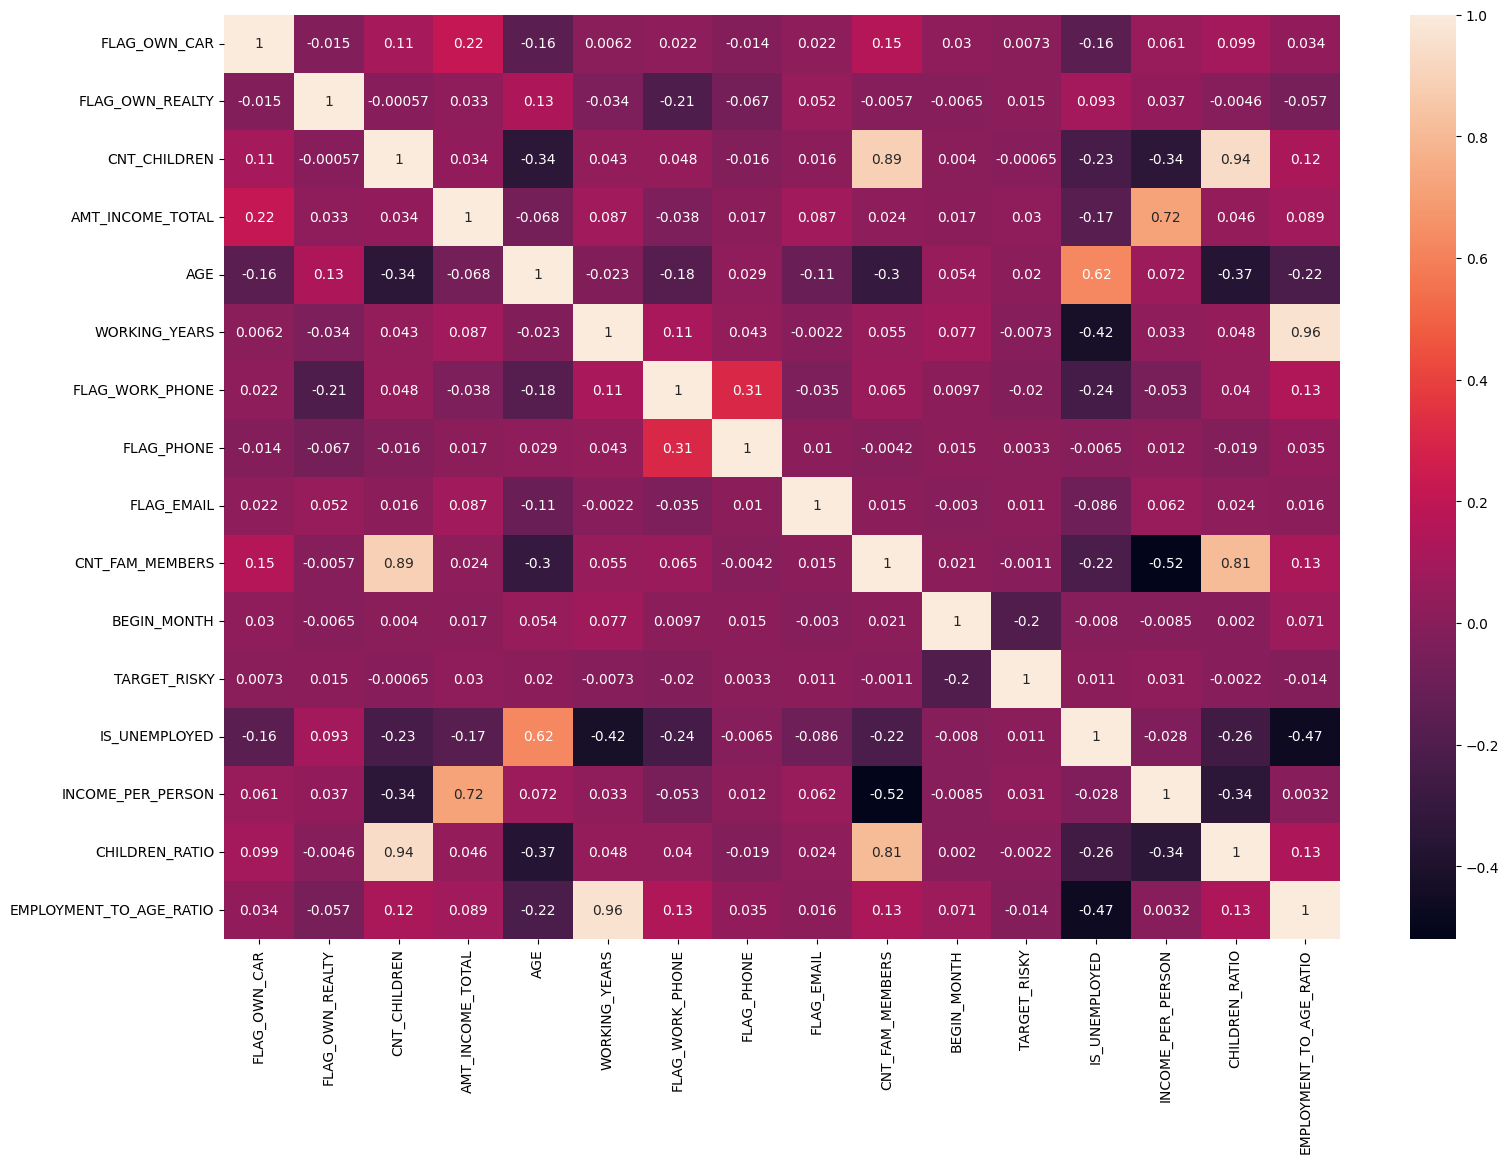

In [67]:
categ=categorical_feat.columns
num_tar=df_model.drop(columns=categ , axis=1)
plt.figure(figsize=(18,12))
correlation = num_tar.corr()
sns.heatmap(correlation, annot=True)

# ***5. PREPROCESSING***

In [68]:
def categorize_job(job):
    if pd.isna(job):
        return np.nan
    if job in ['Laborers','Low-skill Laborers','Drivers','Cleaning staff','Cooking staff','Security staff']:
        return 'Manual'
    elif job in ['Sales staff','Waiters/barmen staff','Private service staff']:
        return 'Service'
    elif job in ['Core staff','High skill tech staff','IT staff','Accountants','Medicine staff']:
        return 'Professional'
    elif job in ['Managers','Realty agents']:
        return 'Management'
    elif job in ['HR staff','Secretaries']:
        return 'Administrative'
    else:
        return job

In [69]:
df_model['OCCUPATION_TYPE'] = df_model['OCCUPATION_TYPE'].apply(categorize_job)

In [70]:
df_model['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Manual,10322
Professional,7482
Service,4003
Management,3091
Administrative,236


## 5.1 TRAIN TEST SPLIT

In [71]:
x=df_model.drop(['TARGET_RISKY'],axis=1)
y=df_model['TARGET_RISKY']

In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=74,stratify=y)

## 5.2 ENGINEERING MISSING VALUES

In [73]:
x_train.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


In [74]:
x_test.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


In [75]:
x[x['OCCUPATION_TYPE'].isnull()]['NAME_EDUCATION_TYPE'].value_counts()

,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,7969
Higher education,2732
Incomplete higher,417
Lower secondary,187
Academic degree,18


In [76]:
x[x['OCCUPATION_TYPE'].isnull()]['WORKING_YEARS'].value_counts()

,count
WORKING_YEARS,
0.00,6135
0.83,33
5.51,29
8.43,26
4.42,25
...,...
0.35,1
16.18,1
0.46,1


In [77]:
x_train['OCCUPATION_MISSING'] = x_train['OCCUPATION_TYPE'].isna().astype(int)
x_test['OCCUPATION_MISSING'] = x_test['OCCUPATION_TYPE'].isna().astype(int)

In [78]:
x_train.loc[x_train['IS_UNEMPLOYED'] == 1, 'OCCUPATION_TYPE'] = 'Unemployed'
x_test.loc[x_test['IS_UNEMPLOYED'] == 1, 'OCCUPATION_TYPE'] = 'Unemployed'

In [79]:
x_train.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


In [80]:
x_test.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


In [81]:
x_train['OCCUPATION_TYPE'] = x_train['OCCUPATION_TYPE'].fillna('Unknown')
x_test['OCCUPATION_TYPE'] = x_test['OCCUPATION_TYPE'].fillna('Unknown')

In [82]:
x_train.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


In [83]:
x_test.isnull().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
AGE,0


# ***6.MODELING***

## 6.1 PREPARE PIPELINES

In [84]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV,cross_val_score
from sklearn.metrics import roc_auc_score,roc_curve
from sklearn.tree import DecisionTreeClassifier

In [85]:
x_train['AGE_GROUP']=x_train['AGE_GROUP'].astype(object)
x_test['AGE_GROUP']=x_test['AGE_GROUP'].astype(object)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [87]:
cat_col=[col for col in x_train.columns if x_train[col].dtypes == 'O']

num_col=[col for col in x_train.columns if x_train[col].dtypes != 'O']

In [88]:
cat_col

['CODE_GENDER',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'AGE_GROUP']

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================
# Preprocessing
# =========================

num_transf = Pipeline(steps=[
    ('scaler', RobustScaler())
])

cat_transf = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transf, num_col),
    ('cat', cat_transf, cat_col)
])

# =========================
# 1) Logistic Regression
# =========================

LR_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=0,
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear'
    ))
])

LR_pd = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.1, 1, 10]
}

LR_rs = RandomizedSearchCV(
    estimator=LR_pipeline,
    param_distributions=LR_pd,
    cv=3,
    scoring='f1',
    n_iter=5,
    n_jobs=-1,
    random_state=0
)

# =========================
# 2) Decision Tree
# =========================

DTC_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=0,
        class_weight='balanced'
    ))
])

DTC_pd = {
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

DTC_rs = RandomizedSearchCV(
    estimator=DTC_pipeline,
    param_distributions=DTC_pd,
    cv=3,
    scoring='f1',
    n_iter=10,
    n_jobs=-1,
    random_state=0
)

# =========================
# 3) Random Forest
# =========================

RFC_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=0,
        class_weight='balanced',
        n_jobs=-1
    ))
])

RFC_pd = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

RFC_rs = RandomizedSearchCV(
    estimator=RFC_pipeline,
    param_distributions=RFC_pd,
    cv=3,
    scoring='f1',
    n_iter=10,
    n_jobs=-1,
    random_state=0
)

# =========================
# 4) Gradient Boosting Classifier
# =========================

GBC_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        random_state=0
    ))
])

GBC_pd = {
    'classifier__n_estimators': [100, 150],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [2, 3],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

GBC_rs = RandomizedSearchCV(
    estimator=GBC_pipeline,
    param_distributions=GBC_pd,
    cv=3,
    scoring='f1',
    n_iter=10,
    n_jobs=-1,
    random_state=0
)

## 6.2 APPLY RANDOM SEARCH

In [90]:
LR_rs.fit(x_train, y_train)
DTC_rs.fit(x_train, y_train)
RFC_rs.fit(x_train, y_train)
GBC_rs.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                RobustScaler())]),
                                                                               ['FLAG_OWN_CAR',
                                                                                'FLAG_OWN_REALTY',
                                                                                'CNT_CHILDREN',
                                                                                'AMT_INCOME_TOTAL',
                                                                                'AGE',
                                                                                'WORKING_YEARS',
                                                                                'FLAG_WORK_PHONE',
                                                                                'FLAG_PHONE',
                                                                                'FLAG_EMAIL',
                                                                                'CNT_FAM_MEMBERS',
                                                                                'BEGIN_MONTH',
                                                                                'IS_UNEMPLOYED',
                                                                                'INCOME_PER_PERSON'...
                                                                                'NAME_HOUSING_TYPE',
                                                                                'OCCUPATION_TYPE',
                                                                                'AGE_GROUP'])])),
                                             ('classifier',
                                              GradientBoostingClassifier(random_state=0))]),
                   n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.05,
                                                                      0.1],
                                        'classifier__max_depth': [2, 3],
                                        'classifier__min_samples_leaf': [1, 2],
                                        'classifier__min_samples_split': [2, 5],
                                        'classifier__n_estimators': [100, 150]},
                   random_state=0, scoring='f1')

In [91]:
print("LR:", LR_rs.best_score_, LR_rs.best_params_)
print("DTC:", DTC_rs.best_score_, DTC_rs.best_params_)
print("RFC:", RFC_rs.best_score_, RFC_rs.best_params_)
print("GBC:", GBC_rs.best_score_, GBC_rs.best_params_)

LR: 0.49160186193512273 {'classifier__penalty': 'l2', 'classifier__C': 0.1}
DTC: 0.5096524187963544 {'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 3}
RFC: 0.5603596273651906 {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 20}
GBC: 0.4027452692830127 {'classifier__n_estimators': 150, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}


In [92]:
print(LR_rs.best_estimator_)
print(DTC_rs.best_estimator_)
print(RFC_rs.best_estimator_)
print(GBC_rs.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL', 'AGE',
                                                   'WORKING_YEARS',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'BEGIN_MONTH',
                                                   'IS_UNEMPLOYED',
                                            

In [93]:
#this is random search best estimator output
LR_Model=LR_rs.best_estimator_
DTC_Model=DTC_rs.best_estimator_
RFC_Model=RFC_rs.best_estimator_
GBC_Model=GBC_rs.best_estimator_

## 6.3 MODEL FITTING

In [94]:
LR_Model.fit(x_train,y_train)
DTC_Model.fit(x_train,y_train)
RFC_Model.fit(x_train,y_train)
GBC_Model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL', 'AGE',
                                                   'WORKING_YEARS',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'BEGIN_MONTH',
                                                   'IS_UNEMPLOYED',
                                                   'INCOME_PER_PERSON',
                                                   'CHILDREN_RATIO',
                                                   'EMPLOYMENT_TO_A...TIO',
                                                   'OCCUPATION_MISSING']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'AGE_GROUP'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            min_samples_leaf=2,
                                            n_estimators=150,
                                            random_state=0))])

## 6.4 MODEL PREDICTION

In [95]:
LR_pred=LR_Model.predict(x_test)
DTC_pred=DTC_Model.predict(x_test)
RFC_pred=RFC_Model.predict(x_test)
GBC_pred=GBC_Model.predict(x_test)

# ***7. MODELS EVALUATION***

In [96]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score

## **7.1 Logestic regression evaluation**

In [97]:
LR_as=accuracy_score(y_test,LR_pred)
LR_as

0.6072408118486012

In [98]:
LR_cr=classification_report(y_test,LR_pred)
print(LR_cr)

              precision    recall  f1-score   support

           0       0.79      0.58      0.67      5028
           1       0.42      0.66      0.51      2264

    accuracy                           0.61      7292
   macro avg       0.60      0.62      0.59      7292
weighted avg       0.68      0.61      0.62      7292



<Axes: >

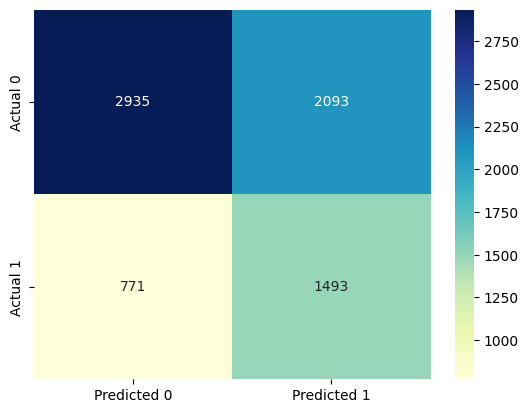

In [99]:
LR_cm=confusion_matrix(y_test,LR_pred)
cm_matrix = pd.DataFrame(data=LR_cm,    columns=['Predicted 0', 'Predicted 1'],
    index=['Actual 0', 'Actual 1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

## **7.2 Decision tree evaluation**

In [100]:
DTC_as=accuracy_score(y_test,DTC_pred)
DTC_as

0.6834887547997806

In [101]:
DTC_cr=classification_report(y_test,DTC_pred)
print(DTC_cr)

              precision    recall  f1-score   support

           0       0.79      0.74      0.76      5028
           1       0.49      0.56      0.53      2264

    accuracy                           0.68      7292
   macro avg       0.64      0.65      0.64      7292
weighted avg       0.70      0.68      0.69      7292



<Axes: >

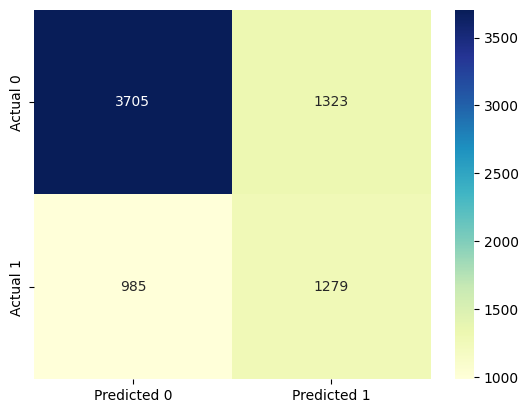

In [102]:
DTC_cm=confusion_matrix(y_test,DTC_pred)
cm_matrix = pd.DataFrame(data=DTC_cm,    columns=['Predicted 0', 'Predicted 1'],
    index=['Actual 0', 'Actual 1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

## **7.3 Random forest evaluation**

In [103]:
RFC_as=accuracy_score(y_test,RFC_pred)
RFC_as

0.742046077893582

In [104]:
RFC_cr=classification_report(y_test,RFC_pred)
print(RFC_cr)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      5028
           1       0.59      0.57      0.58      2264

    accuracy                           0.74      7292
   macro avg       0.70      0.69      0.70      7292
weighted avg       0.74      0.74      0.74      7292



<Axes: >

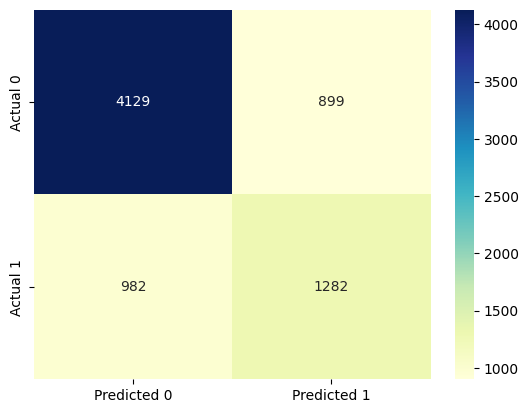

In [105]:
RFC_cm=confusion_matrix(y_test,RFC_pred)
cm_matrix = pd.DataFrame(data=RFC_cm,    columns=['Predicted 0', 'Predicted 1'],
    index=['Actual 0', 'Actual 1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

## **7.4 Gradiant boosting evaluation**

In [106]:
GBC_as=accuracy_score(y_test,GBC_pred)
GBC_as

0.7324465167306637

In [107]:
GBC_cr=classification_report(y_test,GBC_pred)
print(GBC_cr)

              precision    recall  f1-score   support

           0       0.75      0.92      0.83      5028
           1       0.63      0.33      0.43      2264

    accuracy                           0.73      7292
   macro avg       0.69      0.62      0.63      7292
weighted avg       0.71      0.73      0.70      7292



<Axes: >

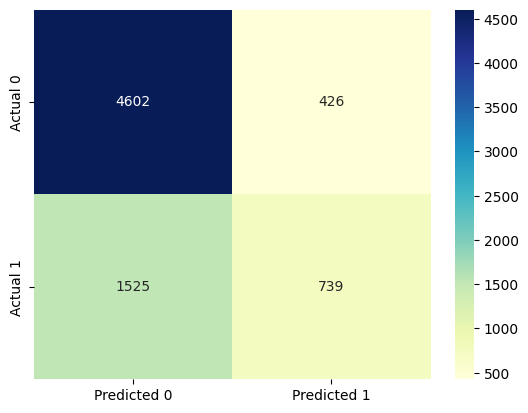

In [108]:
GBC_cm=confusion_matrix(y_test,GBC_pred)
cm_matrix = pd.DataFrame(data=GBC_cm,    columns=['Predicted 0', 'Predicted 1'],
    index=['Actual 0', 'Actual 1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

# ***8. RANDOM FOREST IMPROVEMENT***

## 8.2 Random forest imbalanced data model-improvement wise using bootstrabing

In [109]:
from imblearn.ensemble import BalancedRandomForestClassifier

num_transf=Pipeline(steps=[
    ('scalar',RobustScaler())
])

cat_transf=Pipeline(steps=[
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_transf,num_col),
    ('cat',cat_transf,cat_col)
])

BRFC_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',BalancedRandomForestClassifier(random_state=0))
])

BRFC_pd=[{
    'classifier__n_estimators': [700,900],
    'classifier__max_depth': [30,40],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features' : ['sqrt','log2',None],
    'classifier__bootstrap': [True, False]
}]

BRFC_rs=RandomizedSearchCV(BRFC_pipeline,param_distributions=BRFC_pd,cv=5,scoring='f1',n_iter=30,n_jobs=-1)



In [110]:
BRFC_rs.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scalar',
                                                                                                RobustScaler())]),
                                                                               ['FLAG_OWN_CAR',
                                                                                'FLAG_OWN_REALTY',
                                                                                'CNT_CHILDREN',
                                                                                'AMT_INCOME_TOTAL',
                                                                                'AGE',
                                                                                'WORKING_YEARS',
                                                                                'FLAG_WORK_PHONE',
                                                                                'FLAG_PHONE',
                                                                                'FLAG_EMAIL',
                                                                                'CNT_FAM_MEMBERS',
                                                                                'BEGIN_MONTH',
                                                                                'IS_UNEMPLOYED',
                                                                                'INCOME_PER_PERSON'...
                                             ('classifier',
                                              BalancedRandomForestClassifier(random_state=0))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions=[{'classifier__bootstrap': [True, False],
                                         'classifier__max_depth': [30, 40],
                                         'classifier__max_features': ['sqrt',
                                                                      'log2',
                                                                      None],
                                         'classifier__min_samples_leaf': [1, 2,
                                                                          4],
                                         'classifier__min_samples_split': [2, 5,
                                                                           10],
                                         'classifier__n_estimators': [700,
                                                                      900]}],
                   scoring='f1')

In [111]:
print(BRFC_rs.best_params_)

{'classifier__n_estimators': 900, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 40, 'classifier__bootstrap': False}


In [112]:
BRFC_Model=BRFC_rs.best_estimator_

In [113]:
print(BRFC_rs.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scalar',
                                                                   RobustScaler())]),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL', 'AGE',
                                                   'WORKING_YEARS',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'BEGIN_MONTH',
                                                   'IS_UNEMPLOYED',
                                            

In [114]:
BRFC_Model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scalar',
                                                                   RobustScaler())]),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL', 'AGE',
                                                   'WORKING_YEARS',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'BEGIN_MONTH',
                                                   'IS_UNEMPLOYED',
                                                   'INCOME_PER_PERSON',
                                                   'CHILDREN_RATIO',
                                                   'EMPLOYMENT_TO_A...
                                                   'OCCUPATION_MISSING']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'AGE_GROUP'])])),
                ('classifier',
                 BalancedRandomForestClassifier(max_depth=40,
                                                min_samples_leaf=2,
                                                min_samples_split=10,
                                                n_estimators=900,
                                                random_state=0))])

In [115]:
BRFC_pred=BRFC_Model.predict(x_test)

In [116]:
BRFC_as=accuracy_score(y_test,BRFC_pred)
BRFC_as

0.7354635216675809

In [117]:
BRFC_cr=classification_report(y_test,BRFC_pred)
print(BRFC_cr)

              precision    recall  f1-score   support

           0       0.83      0.78      0.80      5028
           1       0.56      0.65      0.60      2264

    accuracy                           0.74      7292
   macro avg       0.70      0.71      0.70      7292
weighted avg       0.75      0.74      0.74      7292



<Axes: >

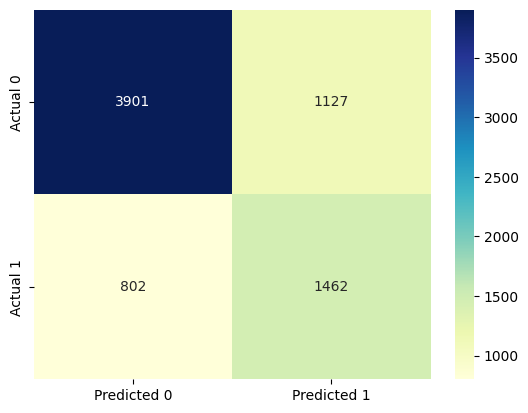

In [118]:
BRFC_cm=confusion_matrix(y_test,BRFC_pred)
cm_matrix = pd.DataFrame(data=BRFC_cm,    columns=['Predicted 0', 'Predicted 1'],
    index=['Actual 0', 'Actual 1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [119]:
BRFC_prob = BRFC_Model.predict_proba(x_test)[:, 1]
roc_auc_score(y_test, BRFC_prob)

np.float64(0.7831832111202004)

## 8.3 Random forest imbalanced data data-improvement wise using TomekLinks

In [120]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks


num_transf = Pipeline(steps=[
    ('scaler', RobustScaler())
])

cat_transf = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transf, num_col),
    ('cat', cat_transf, cat_col)
])


RFC_Tomek_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('tomek', TomekLinks()),
    ('classifier', RandomForestClassifier(
        random_state=0,
        class_weight='balanced'
    ))
])


RFC_Tomek_pd = {
    'classifier__n_estimators': [300, 500, 700],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}


RFC_Tomek_rs = RandomizedSearchCV(
    estimator=RFC_Tomek_pipeline,
    param_distributions=RFC_Tomek_pd,
    cv=5,
    scoring='f1',
    n_iter=30,
    n_jobs=-1,
    random_state=0
)

In [121]:
RFC_Tomek_rs.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                RobustScaler())]),
                                                                               ['FLAG_OWN_CAR',
                                                                                'FLAG_OWN_REALTY',
                                                                                'CNT_CHILDREN',
                                                                                'AMT_INCOME_TOTAL',
                                                                                'AGE',
                                                                                'WORKING_YEARS',
                                                                                'FLAG_WORK_PHONE',
                                                                                'FLAG_PHONE',
                                                                                'FLAG_EMAIL',
                                                                                'CNT_FAM_MEMBERS',
                                                                                'BEGIN_MONTH',
                                                                                'IS_UNEMPLOYED',
                                                                                'INCOME_PER_PERSON'...
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=0))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [300, 500,
                                                                     700]},
                   random_state=0, scoring='f1')

In [122]:
print(RFC_Tomek_rs.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL', 'AGE',
                                                   'WORKING_YEARS',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'BEGIN_MONTH',
                                                   'IS_UNEMPLOYED',
                                            

In [123]:
RFC_Tomek_Model=RFC_Tomek_rs.best_estimator_

In [124]:
RFC_Tomek_Model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL', 'AGE',
                                                   'WORKING_YEARS',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'BEGIN_MONTH',
                                                   'IS_UNEMPLOYED',
                                                   'INCOME_PER_PERSON',
                                                   'CHILDREN_RATIO',
                                                   'EMPLOYMENT_TO_A...
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'AGE_GROUP'])])),
                ('tomek', TomekLinks()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=0))])

In [125]:
RFC_Tomek_pred=RFC_Tomek_Model.predict(x_test)

In [126]:
RFC_Tomek_as=accuracy_score(y_test,RFC_Tomek_pred)
RFC_Tomek_as

0.7366977509599562

In [127]:
RFC_Tomek_cr=classification_report(y_test,RFC_Tomek_pred)
print(RFC_Tomek_cr)

              precision    recall  f1-score   support

           0       0.82      0.79      0.80      5028
           1       0.57      0.62      0.59      2264

    accuracy                           0.74      7292
   macro avg       0.70      0.71      0.70      7292
weighted avg       0.74      0.74      0.74      7292



<Axes: >

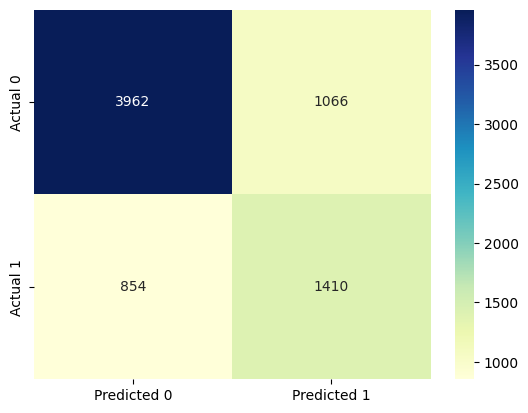

In [128]:
RFC_Tomek_cm=confusion_matrix(y_test,RFC_Tomek_pred)
cm_matrix = pd.DataFrame(data=RFC_Tomek_cm, columns=['Predicted 0', 'Predicted 1'],
    index=['Actual 0', 'Actual 1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [129]:
RFC_Tomek_prob = RFC_Tomek_Model.predict_proba(x_test)[:, 1]
roc_auc_score(y_test, RFC_Tomek_prob)

np.float64(0.7787780215246914)

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.ensemble import BalancedBaggingClassifier

# =========================
# Preprocessing
# =========================

num_transf = Pipeline(steps=[
    ('scaler', RobustScaler())
])

cat_transf = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transf, num_col),
    ('cat', cat_transf, cat_col)
])

# =========================
# Balanced Bagging
# =========================

BBC_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(
            random_state=0,
            max_depth=5
        ),
        random_state=0,
        n_jobs=-1
    ))
])

BBC_pd = {
    'classifier__n_estimators': [300,400],
    'classifier__max_samples': [0.5, 0.8],
    'classifier__max_features': [0.7, 1.0],
    'classifier__sampling_strategy': ['auto'],
    'classifier__replacement': [False, True],
    'classifier__estimator__max_depth': [3, 5, 7],
    'classifier__estimator__min_samples_leaf': [1, 3, 5]
}

BBC_rs = RandomizedSearchCV(
    estimator=BBC_pipeline,
    param_distributions=BBC_pd,
    cv=3,
    scoring='recall',
    n_iter=10,
    n_jobs=-1,
    random_state=0
)

In [131]:
BBC_rs.fit(x_train, y_train)

print("Best Score:", BBC_rs.best_score_)
print("Best Params:", BBC_rs.best_params_)

Best Score: 0.575972818640035
Best Params: {'classifier__sampling_strategy': 'auto', 'classifier__replacement': True, 'classifier__n_estimators': 300, 'classifier__max_samples': 0.5, 'classifier__max_features': 0.7, 'classifier__estimator__min_samples_leaf': 1, 'classifier__estimator__max_depth': 7}


In [132]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

BBC_model = BBC_rs.best_estimator_

y_pred = BBC_model.predict(x_test)
y_prob = BBC_model.predict_proba(x_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

[[3774 1254]
 [ 934 1330]]
              precision    recall  f1-score   support

           0       0.80      0.75      0.78      5028
           1       0.51      0.59      0.55      2264

    accuracy                           0.70      7292
   macro avg       0.66      0.67      0.66      7292
weighted avg       0.71      0.70      0.70      7292

ROC-AUC: 0.7241827831282627
PR-AUC: 0.5489306807559622


# ***9. Models Evaluations Comparison***

## **9.1 Evaluations**

In [133]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    'Logistic Regression': LR_Model,
    'Decision Tree': DTC_Model,
    'Random Forest': RFC_Model,
    'Gradient Boosting': GBC_Model,
    'Balanced Random Forest': BRFC_Model,
    'Random Forest + Tomek': RFC_Tomek_Model,
    'Balanced Bagging': BBC_model
}

results = []

for model_name, model in models.items():

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision Risky': precision_score(
            y_test, y_pred, pos_label=1, zero_division=0
        ),
        'Recall Risky': recall_score(
            y_test, y_pred, pos_label=1, zero_division=0
        ),
        'F1 Risky': f1_score(
            y_test, y_pred, pos_label=1, zero_division=0
        ),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)

display(results_df.round(3))

,Model,Accuracy,Precision Risky,Recall Risky,F1 Risky,ROC-AUC
4,Balanced Random Forest,0.73,0.56,0.65,0.60,0.78
5,Random Forest + Tomek,0.74,0.57,0.62,0.59,0.78
2,Random Forest,0.74,0.59,0.57,0.58,0.78
6,Balanced Bagging,0.70,0.52,0.59,0.55,0.72
3,Gradient Boosting,0.73,0.63,0.33,0.43,0.72
1,Decision Tree,0.68,0.49,0.56,0.53,0.70
0,Logistic Regression,0.61,0.42,0.66,0.51,0.65


## **9.2 ROC_AUC Curves**

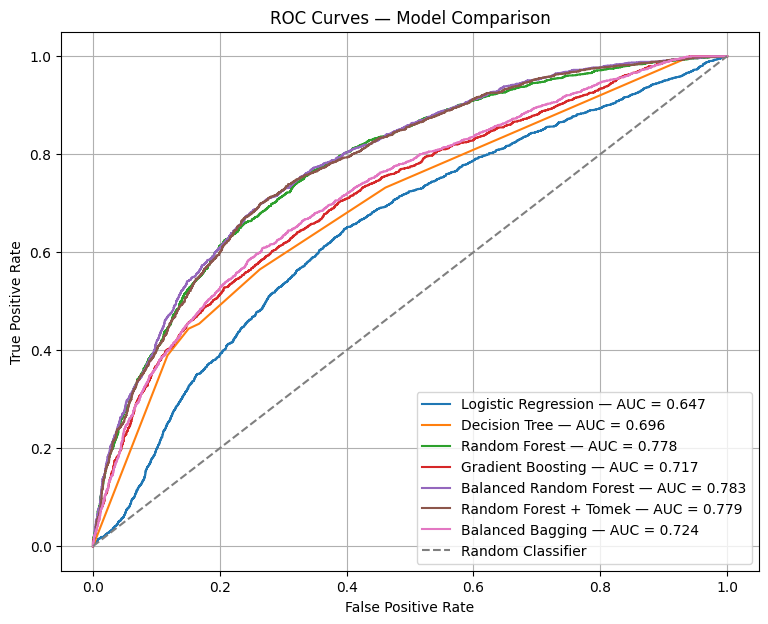

In [134]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(9, 7))

for model_name, model in models.items():

    y_prob = model.predict_proba(x_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} — AUC = {auc_score:.3f}'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.grid()
plt.show()

# ***Final Model Selection***

Balanced Random Forest was selected as the final model because it achieved
the best overall balance between risky-applicant recall, F1 score, and
ROC-AUC.

Although the standard Random Forest achieved slightly higher accuracy,
Balanced Random Forest detected a larger proportion of risky applicants.
This is important in credit-risk applications because approving a risky
customer can lead to financial loss.

# ***Conclusion***

Several classification algorithms were trained and compared. Balanced Random
Forest provided the best balance between detecting risky applicants and
maintaining acceptable overall accuracy.

The model can support credit approval decisions, but it should be used as a
decision-support system rather than as a fully automated approval mechanism.


# ***Limitations***

- The approval target was engineered from historical payment behavior because
  the original data did not include a direct Approval_Status column.
- The available application variables provide limited information about the
  applicant's complete creditworthiness.
- The model may require recalibration when applied to a different population
  or time period.